In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Summary of the dataframe with results from our 3 models
model_results = pd.DataFrame({
    'Model': [
        'RF default', 'RF depth limited', 'RF regularized',
        'XGB default', 'XGB feature subsampling', 'XGB regularized',
        'LGBM default', 'LGBM feature subsampling', 'LGBM regularized'
    ],
    'Validation_RMSE': [
        1.1743, 1.5541, 2.6775,
        0.0840, 0.3015, 2.5357,
        0.0976, 0.2013, 2.5742
    ]
})

# Sort by validation RMSE
best_model = model_results.sort_values(by='Validation_RMSE').reset_index(drop=True)
print("Best model based on validation RMSE:")
print(best_model.head(1))


Best model based on validation RMSE:
         Model  Validation_RMSE
0  XGB default            0.084


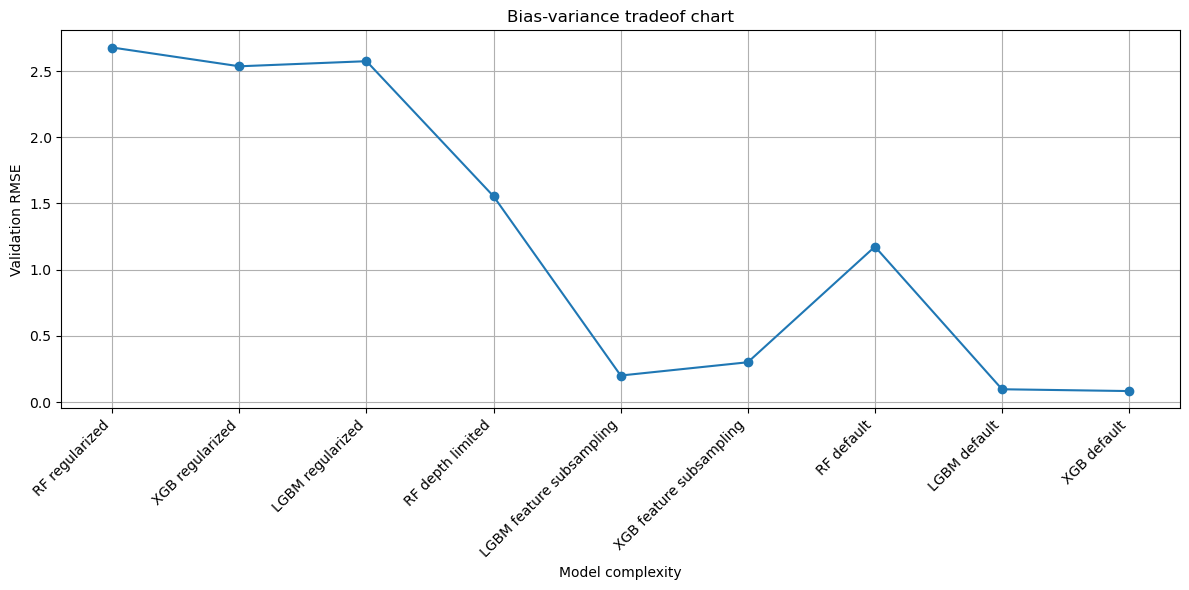

In [3]:
# Bias-Variance tradeoff chart
# Define model complexity order from simplest to most complex
models_ordered = [
    'RF regularized', 
    'XGB regularized', 
    'LGBM regularized', 
    'RF depth limited', 
    'LGBM feature subsampling', 
    'XGB feature subsampling', 
    'RF default', 
    'LGBM default', 
    'XGB default'
]

# Corresponding validation RMSE
validation_rmse = [
    2.6775,  # RF regularized
    2.5357,  # XGB regularized
    2.5742,  # LGBM regularized
    1.5541,  # RF depth limited
    0.2013,  # LGBM feature subsampling
    0.3015,  # XGB feature subsampling
    1.1743,  # RF default
    0.0976,  # LGBM default
    0.0840   # XGB default
]

# Create a dataframe for plotting
bias_variance_df = pd.DataFrame({
    'Model': models_ordered,
    'Validation_RMSE': validation_rmse
})

# Plot the chart
plt.figure(figsize=(12, 6))
plt.plot(bias_variance_df['Model'], bias_variance_df['Validation_RMSE'], marker='o', linestyle='-')
plt.xticks(rotation=45, ha='right')
plt.title('Bias-variance tradeof chart')
plt.xlabel('Model complexity')
plt.ylabel('Validation RMSE')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Load the datasets
train_df = pd.read_csv("../Data/train_data.csv")
val_df = pd.read_csv("../Data/val_data.csv")
test_df = pd.read_csv("../Data/test_data.csv")
# This path works with the current GitHub repo structure that the notebook is in 'notebooks' and the data files are in a sibling 'data' folder

# Pivot to wide format
train_wide = train_df.pivot_table(index=["country_name", "year"], columns="series_name", values="value").reset_index()
val_wide = val_df.pivot_table(index=["country_name", "year"], columns="series_name", values="value").reset_index()
test_wide = test_df.pivot_table(index=["country_name", "year"], columns="series_name", values="value").reset_index()

# Define target variable
target_col = "Life expectancy at birth, total (years)"

train_wide = train_wide.dropna(subset=[target_col])
val_wide = val_wide.dropna(subset=[target_col])
test_wide = test_wide.dropna(subset=[target_col])

# Fill missing values with the mean
train_wide = train_wide.fillna(train_wide.mean(numeric_only=True))
val_wide = val_wide.fillna(val_wide.mean(numeric_only=True))
test_wide = test_wide.fillna(test_wide.mean(numeric_only=True))

# Prepare x and y
drop_cols = [target_col, "country_name", "year"]

X_train = train_wide.drop(columns=drop_cols)
y_train = train_wide[target_col]

X_val = val_wide.drop(columns=drop_cols)
y_val = val_wide[target_col]

X_test = test_wide.drop(columns=drop_cols)
y_test = test_wide[target_col]

# Train the XGB default model
xgb_default = XGBRegressor(n_estimators=100, learning_rate=0.1,
                           colsample_bytree=1.0, subsample=1.0,
                           random_state=42)

xgb_default.fit(X_train, y_train)

# Predict on the test set
y_test_pred = xgb_default.predict(X_test)

# Evaluate model
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print(f"XGB default on test RMSE: {test_rmse:.4f}")
print(f"XGB default on test R-squared: {test_r2:.4f}")


XGB default on test RMSE: 1.8143
XGB default on test R-squared: 0.9508
